In [94]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [95]:
df_exploded=df.explode('job_skills')

In [96]:
df_exploded=df_exploded.groupby(['job_title_short','job_skills']).size()

In [97]:
df_exploded=df_exploded.reset_index(name='job_count')

In [98]:
job_list=df_exploded['job_title_short'].value_counts().index.to_list()[1:4]

In [99]:
df_exploded=df_exploded[df_exploded['job_title_short'].isin(job_list)]

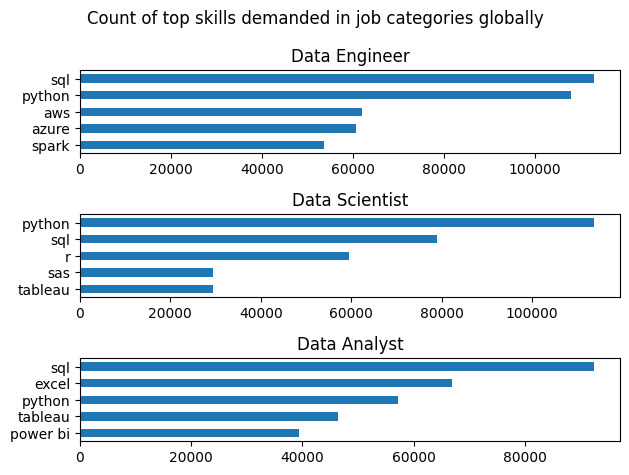

In [100]:
fig,ax=plt.subplots(3,1) 
plt.suptitle("Count of top skills demanded in job categories globally")
for i,val in enumerate(job_list): 
    df_exploded[df_exploded['job_title_short']==val].sort_values('job_count',ascending=False).head().plot(kind='barh',ax=ax[i],x='job_skills',legend=False,title=val)
    ax[i].set_ylabel("")
    ax[i].invert_yaxis()
    plt.tight_layout()

In [101]:
df_jobs=df['job_title_short'].value_counts()


In [102]:
df_jobs=df_jobs.reset_index(name='total_jobs')

In [103]:
df_exploded=df_exploded.merge(df_jobs,on='job_title_short')

In [104]:
df_exploded['job_percent']=(df_exploded['job_count']/df_exploded['total_jobs'])*100

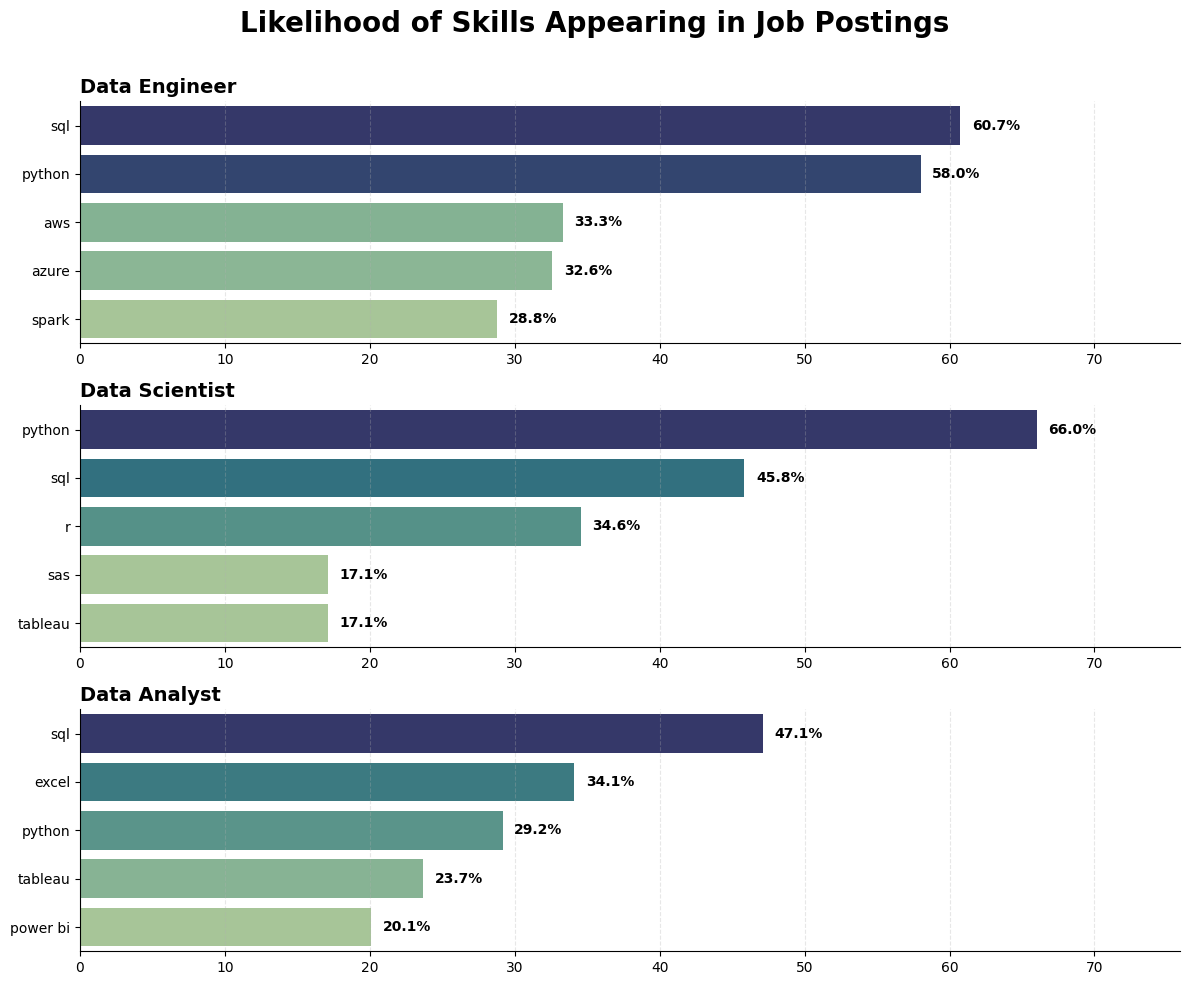

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 3 job titles
job_list = (
    df_exploded['job_title_short']
    .value_counts()
    .head(3)
    .index
    .tolist()
)

# Create figure
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

fig.suptitle(
    'Likelihood of Skills Appearing in Job Postings',
    fontsize=20,
    fontweight='bold'
)

# Keep same scale across all plots
max_percent = (
    df_exploded[df_exploded['job_title_short'].isin(job_list)]
    ['job_percent']
    .max()
)

for i, val in enumerate(job_list):

    plot_data = (
        df_exploded[df_exploded['job_title_short'] == val]
        .sort_values('job_percent', ascending=False)
        .head(5)
    )

    sns.barplot(
        data=plot_data,
        x='job_percent',
        y='job_skills',
        hue='job_percent',
        palette='crest',
        legend=False,
        ax=ax[i]
    )

    # Job title
    ax[i].set_title(
        val,
        fontsize=14,
        fontweight='bold',
        loc='left'
    )

    # Put highest skill on top
    ax[i].invert_yaxis()

    # Percentage labels
    for j, value in enumerate(plot_data['job_percent']):
        ax[i].text(
            value + 0.8,
            j,
            f'{value:.1f}%',
            va='center',
            fontsize=10,
            fontweight='bold'
        )

    # Formatting
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')

    ax[i].set_xlim(0, max_percent * 1.15)

    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

    ax[i].grid(
        axis='x',
        linestyle='--',
        alpha=0.3
    )
    ax[i].invert_yaxis()

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()